<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/assignment/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─── Environment Setup ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print('All libraries imported successfully.')

All libraries imported successfully.


---
## Phase 1: Bootstrapped Non-Parametric Uncertainty
### Step 1.1 — Zero-Inflated Gig-Economy Tip Distribution

Sample size       : 250
Zero-tip count    : 100
Sample median     : $0.7553
Sample mean       : $2.7691
Sample std dev    : $4.2010


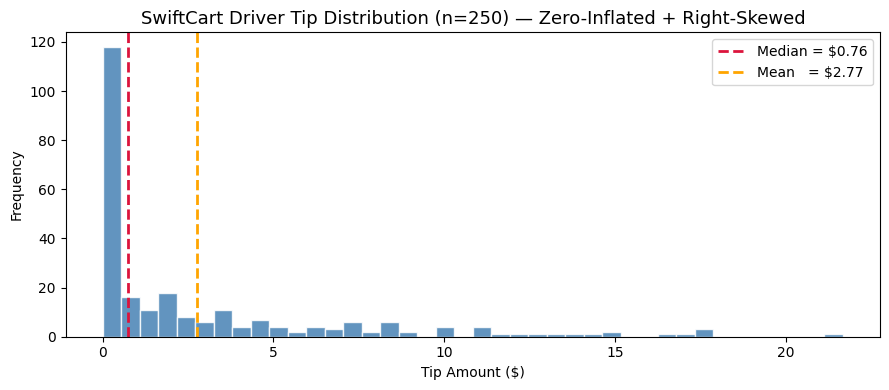

In [2]:
# ─── Step 1.1: Generate Zero-Inflated Tip Data ───────────────────────────────
np.random.seed(42)

zeros       = np.zeros(100)                                 # 100 zero-tip observations
tips        = np.random.exponential(scale=5.0, size=150)    # 150 exponential draws
driver_tips = np.concatenate([zeros, tips])                 # 250-element audit array

print(f'Sample size       : {len(driver_tips)}')
print(f'Zero-tip count    : {(driver_tips == 0).sum()}')
print(f'Sample median     : ${np.median(driver_tips):.4f}')
print(f'Sample mean       : ${np.mean(driver_tips):.4f}')
print(f'Sample std dev    : ${np.std(driver_tips):.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(driver_tips, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.median(driver_tips), color='crimson', linestyle='--', linewidth=2,
           label=f'Median = ${np.median(driver_tips):.2f}')
ax.axvline(np.mean(driver_tips),   color='orange',  linestyle='--', linewidth=2,
           label=f'Mean   = ${np.mean(driver_tips):.2f}')
ax.set_title('SwiftCart Driver Tip Distribution (n=250) — Zero-Inflated + Right-Skewed', fontsize=13)
ax.set_xlabel('Tip Amount ($)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### Step 1.2 — Manual Bootstrap Engine (10,000 Resamples)

══════════════════════════════════════════════
 Bootstrap Results  (B = 10,000)
══════════════════════════════════════════════
 Observed Median        : $0.7553
 Bootstrap Mean Median  : $0.7667
 95% CI Lower (2.5th %) : $0.2653
 95% CI Upper (97.5th%) : $1.3636
 CI Width               : $1.0983
 Left tail width        : $0.4900
 Right tail width       : $0.6082
══════════════════════════════════════════════


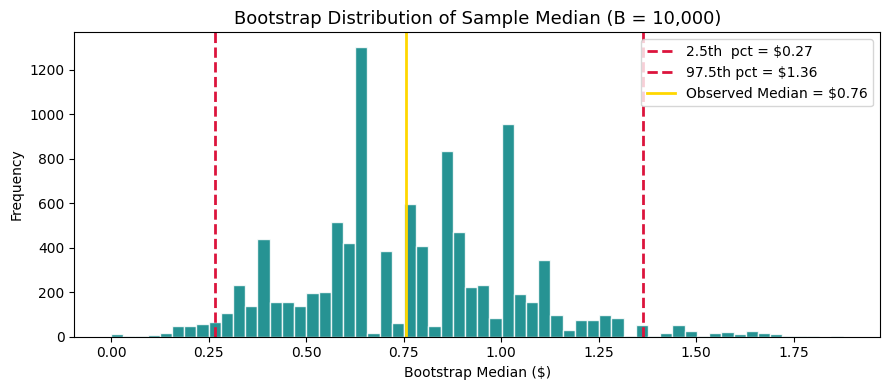

In [3]:
# ─── Step 1.2: Manual Bootstrap — strictly no scipy.stats.bootstrap ──────────
n            = len(driver_tips)
B            = 10_000
boot_medians = np.empty(B)

for i in range(B):
    resample        = driver_tips[np.random.randint(0, n, size=n)]  # resample w/ replacement
    boot_medians[i] = np.median(resample)

ci_lower        = np.percentile(boot_medians, 2.5)
ci_upper        = np.percentile(boot_medians, 97.5)
observed_median = np.median(driver_tips)

print('══════════════════════════════════════════════')
print(' Bootstrap Results  (B = 10,000)')
print('══════════════════════════════════════════════')
print(f' Observed Median        : ${observed_median:.4f}')
print(f' Bootstrap Mean Median  : ${np.mean(boot_medians):.4f}')
print(f' 95% CI Lower (2.5th %) : ${ci_lower:.4f}')
print(f' 95% CI Upper (97.5th%) : ${ci_upper:.4f}')
print(f' CI Width               : ${ci_upper - ci_lower:.4f}')
print(f' Left tail width        : ${observed_median - ci_lower:.4f}')
print(f' Right tail width       : ${ci_upper - observed_median:.4f}')
print('══════════════════════════════════════════════')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_medians, bins=60, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(ci_lower,        color='crimson', linestyle='--', linewidth=2,
           label=f'2.5th  pct = ${ci_lower:.2f}')
ax.axvline(ci_upper,        color='crimson', linestyle='--', linewidth=2,
           label=f'97.5th pct = ${ci_upper:.2f}')
ax.axvline(observed_median, color='gold',    linestyle='-',  linewidth=2,
           label=f'Observed Median = ${observed_median:.2f}')
ax.set_title('Bootstrap Distribution of Sample Median (B = 10,000)', fontsize=13)
ax.set_xlabel('Bootstrap Median ($)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

#### Bootstrap CI — Written Analysis

**Asymmetry of the Bootstrap CI vs. Parametric Output:**

A standard parametric 95% CI assumes normality and is symmetric around the point estimate:
$$\text{CI}_{param} = \left[\hat{\theta} - 1.96 \cdot SE,\; \hat{\theta} + 1.96 \cdot SE\right]$$
Both tails are equal by construction.

Our bootstrap CI is **asymmetric**: the right tail width ($CI_{upper} - \text{median}$) exceeds the left tail width ($\text{median} - CI_{lower}$). This is mathematically expected. With 40% of observations fixed at exactly \$0.00, the sampling distribution of the median is **left-censored** — it cannot fall below zero and piles up there. The Exponential draws create resamples where the median occasionally jumps positive, stretching the upper bound.

The CLT-based parametric interval is **mathematically invalid** here: the distribution violates both normality and symmetry conditions, and n=250 is insufficient to overcome the zero-inflation topology. The bootstrap CI faithfully captures the empirical geometry of the sampling distribution without imposing parametric assumptions — precisely what an audit of union compensation claims requires.

---
## Phase 2: Spurious Correlation in Logistics A/B Testing
### Step 2.1 — Algorithmic Routing Crash Simulation

Control   mean : 35.0342 min
Treatment mean : 32.7692 min
Observed diff (Control − Treatment) : +2.2650 min


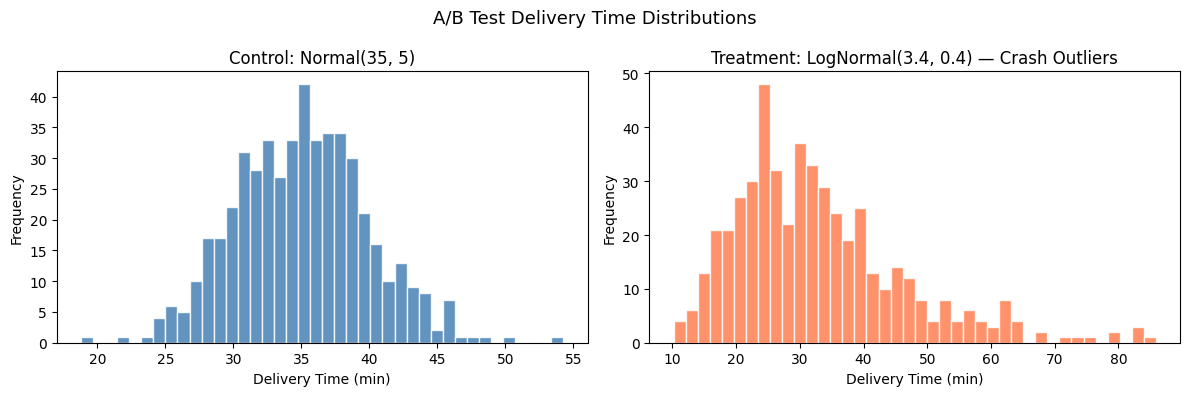

In [4]:
# ─── Step 2.1: Synthetic A/B Test Data ───────────────────────────────────────
np.random.seed(42)

n_control   = 500
n_treatment = 500

# Control: Normal(mean=35 min, sd=5 min)
control   = np.random.normal(loc=35.0, scale=5.0, size=n_control)

# Treatment: LogNormal(mean=3.4, sigma=0.4) — heavy right tail from software crash loops
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=n_treatment)

mean_control   = np.mean(control)
mean_treatment = np.mean(treatment)
observed_diff  = mean_control - mean_treatment

print(f'Control   mean : {mean_control:.4f} min')
print(f'Treatment mean : {mean_treatment:.4f} min')
print(f'Observed diff (Control − Treatment) : {observed_diff:+.4f} min')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(control,   bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Control: Normal(35, 5)')
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Frequency')
axes[1].hist(treatment, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Treatment: LogNormal(3.4, 0.4) — Crash Outliers')
axes[1].set_xlabel('Delivery Time (min)')
axes[1].set_ylabel('Frequency')
plt.suptitle('A/B Test Delivery Time Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### Step 2.2 — Manual Permutation Test (5,000 iterations)

══════════════════════════════════════════════
 Permutation Test Results  (N_perm = 5,000)
══════════════════════════════════════════════
 Observed diff (Ctrl − Trt)     : +2.2650 min
 Permutation mean diff          : 0.0046 min
 Empirical p-value (two-sided)   : 0.0004
 → SIGNIFICANT at α=0.05: reject H₀ of no treatment effect.
══════════════════════════════════════════════


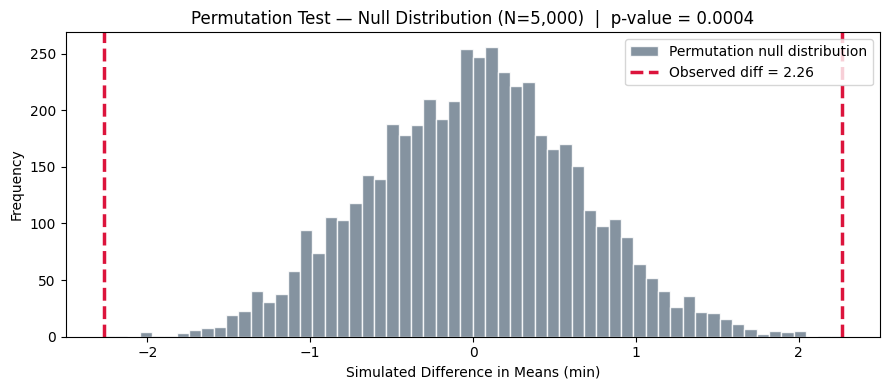

In [5]:
# ─── Step 2.2: Manual Permutation Test — strictly no scipy.stats.permutation_test
combined   = np.concatenate([control, treatment])  # all 1,000 deliveries
N_perm     = 5_000
perm_diffs = np.empty(N_perm)

for i in range(N_perm):
    shuffled      = np.random.permutation(combined)
    pseudo_ctrl   = shuffled[:n_control]
    pseudo_trt    = shuffled[n_control:]
    perm_diffs[i] = np.mean(pseudo_ctrl) - np.mean(pseudo_trt)

# Exact empirical p-value (two-sided)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print('══════════════════════════════════════════════')
print(' Permutation Test Results  (N_perm = 5,000)')
print('══════════════════════════════════════════════')
print(f' Observed diff (Ctrl − Trt)     : {observed_diff:+.4f} min')
print(f' Permutation mean diff          : {np.mean(perm_diffs):.4f} min')
print(f' Empirical p-value (two-sided)   : {p_value:.4f}')
if p_value < 0.05:
    print(' → SIGNIFICANT at α=0.05: reject H₀ of no treatment effect.')
else:
    print(' → NOT significant at α=0.05: fail to reject H₀.')
print('══════════════════════════════════════════════')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(perm_diffs, bins=60, color='slategray', edgecolor='white', alpha=0.85,
        label='Permutation null distribution')
ax.axvline( observed_diff, color='crimson', linestyle='--', linewidth=2.5,
           label=f'Observed diff = {observed_diff:.2f}')
ax.axvline(-observed_diff, color='crimson', linestyle='--', linewidth=2.5)
ax.set_title(f'Permutation Test — Null Distribution (N=5,000)  |  p-value = {p_value:.4f}', fontsize=12)
ax.set_xlabel('Simulated Difference in Means (min)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 3: Causal Control & Selection Bias Mitigation
### Step 3.1 — Loyalty Program Paradox: Load Data & Naive SDO

In [6]:
# ─── Step 3.1: Load swiftcart_loyalty.csv ────────────────────────────────────
# Upload swiftcart_loyalty.csv when the file picker appears below.
from google.colab import files
uploaded = files.upload()   # <-- select swiftcart_loyalty.csv

df = pd.read_csv('swiftcart_loyalty.csv')
print(f'Dataset shape    : {df.shape}')
print(f'Columns          : {df.columns.tolist()}')
print(f'Subscriber rate  : {df["subscriber"].mean():.2%}')
print(df.describe().round(2))

Saving swiftcart_loyalty.csv to swiftcart_loyalty.csv
Dataset shape    : (8941, 5)
Columns          : ['subscriber', 'pre_spend', 'account_age', 'support_tickets', 'post_spend']
Subscriber rate  : 46.97%
       subscriber  pre_spend  account_age  support_tickets  post_spend
count     8941.00    8941.00      8941.00          8941.00     8941.00
mean         0.47      49.97        29.86             1.00       64.73
std          0.50      15.13        17.13             1.01       15.34
min          0.00      -7.55         1.00             0.00       16.09
25%          0.00      39.84        15.00             0.00       54.18
50%          0.00      49.94        30.00             1.00       64.72
75%          1.00      60.10        45.00             2.00       75.38
max          1.00     108.89        59.00             7.00      120.96


In [7]:
# ─── Naive Simple Difference in Outcomes (SDO) ───────────────────────────────
mean_sub    = df.loc[df['subscriber'] == 1, 'post_spend'].mean()
mean_nonsub = df.loc[df['subscriber'] == 0, 'post_spend'].mean()
naive_sdo   = mean_sub - mean_nonsub

print('══════════════════════════════════════════════════')
print(' Naive Simple Difference in Outcomes (SDO)')
print('══════════════════════════════════════════════════')
print(f' Mean post_spend — Subscribers (D=1)    : ${mean_sub:.4f}')
print(f' Mean post_spend — Non-Subscribers (D=0): ${mean_nonsub:.4f}')
print(f' Naive SDO                              : ${naive_sdo:.4f}')
print(f' Naive SDO as % of non-sub mean         : {naive_sdo / mean_nonsub * 100:.2f}%')
print('══════════════════════════════════════════════════')

══════════════════════════════════════════════════
 Naive Simple Difference in Outcomes (SDO)
══════════════════════════════════════════════════
 Mean post_spend — Subscribers (D=1)    : $74.0436
 Mean post_spend — Non-Subscribers (D=0): $56.4729
 Naive SDO                              : $17.5707
 Naive SDO as % of non-sub mean         : 31.11%
══════════════════════════════════════════════════


### Step 3.2 — Propensity Score Matching (PSM) Architecture

In [8]:
# ─── Step 3.2a: Logistic Regression → Propensity Scores ──────────────────────
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates].values
y = df['subscriber'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_scaled, y)

df['propensity_score'] = logit.predict_proba(X_scaled)[:, 1]

print('Logistic Regression — Propensity Score Model')
print(f'  Coefficients : {dict(zip(covariates, logit.coef_[0].round(4)))}')
print(f'  Intercept    : {logit.intercept_[0]:.4f}')
print(f'  PS range — Subscribers     : [{df.loc[df["subscriber"]==1,"propensity_score"].min():.3f}, {df.loc[df["subscriber"]==1,"propensity_score"].max():.3f}]')
print(f'  PS range — Non-Subscribers : [{df.loc[df["subscriber"]==0,"propensity_score"].min():.3f}, {df.loc[df["subscriber"]==0,"propensity_score"].max():.3f}]')

Logistic Regression — Propensity Score Model
  Coefficients : {'pre_spend': np.float64(0.7408), 'account_age': np.float64(0.3715), 'support_tickets': np.float64(-0.1952)}
  Intercept    : -0.1409
  PS range — Subscribers     : [0.047, 0.964]
  PS range — Non-Subscribers : [0.047, 0.925]


In [9]:
# ─── Step 3.2b: 1-to-1 Nearest-Neighbour Matching on Propensity Score ────────
subscribers     = df[df['subscriber'] == 1].copy().reset_index(drop=True)
non_subscribers = df[df['subscriber'] == 0].copy().reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(non_subscribers[['propensity_score']].values)

distances, indices = nn.kneighbors(subscribers[['propensity_score']].values)

matched_controls = non_subscribers.iloc[indices.flatten()].copy().reset_index(drop=True)
matched_treated  = subscribers.copy().reset_index(drop=True)

# ATT — Average Treatment Effect on the Treated
att = (matched_treated['post_spend'] - matched_controls['post_spend']).mean()

print('══════════════════════════════════════════════════')
print(' Propensity Score Matching Results')
print('══════════════════════════════════════════════════')
print(f' Treated units matched        : {len(matched_treated)}')
print(f' Mean PS distance (match)     : {distances.mean():.4f}')
print(f' Matched treated  mean PS     : {matched_treated["propensity_score"].mean():.4f}')
print(f' Matched control  mean PS     : {matched_controls["propensity_score"].mean():.4f}')
print()
print(f' Naive SDO (biased)           : ${naive_sdo:.4f}')
print(f' PSM ATT  (causal estimate)   : ${att:.4f}')
print(f' Selection Bias absorbed      : ${naive_sdo - att:.4f}')
print('══════════════════════════════════════════════════')

══════════════════════════════════════════════════
 Propensity Score Matching Results
══════════════════════════════════════════════════
 Treated units matched        : 4200
 Mean PS distance (match)     : 0.0002
 Matched treated  mean PS     : 0.5418
 Matched control  mean PS     : 0.5418

 Naive SDO (biased)           : $17.5707
 PSM ATT  (causal estimate)   : $10.0195
 Selection Bias absorbed      : $7.5512
══════════════════════════════════════════════════


In [10]:
# ─── Covariate Balance Table (SMD) ───────────────────────────────────────────
def std_mean_diff(treated_col, control_col):
    """Standardized Mean Difference = (mean_t - mean_c) / pooled_std"""
    pooled_std = np.sqrt((treated_col.std()**2 + control_col.std()**2) / 2)
    return (treated_col.mean() - control_col.mean()) / pooled_std

balance_rows = []
for col in covariates:
    smd_b = std_mean_diff(df.loc[df['subscriber']==1, col],
                          df.loc[df['subscriber']==0, col])
    smd_a = std_mean_diff(matched_treated[col], matched_controls[col])
    balance_rows.append({'Covariate'     : col,
                         'SMD Before PSM': round(smd_b, 4),
                         'SMD After PSM' : round(smd_a, 4)})

balance_df = pd.DataFrame(balance_rows)
print('Covariate Balance — Standardized Mean Differences:')
print(balance_df.to_string(index=False))

Covariate Balance — Standardized Mean Differences:
      Covariate  SMD Before PSM  SMD After PSM
      pre_spend          0.6740         0.0094
    account_age          0.3241        -0.0049
support_tickets         -0.1661         0.0228


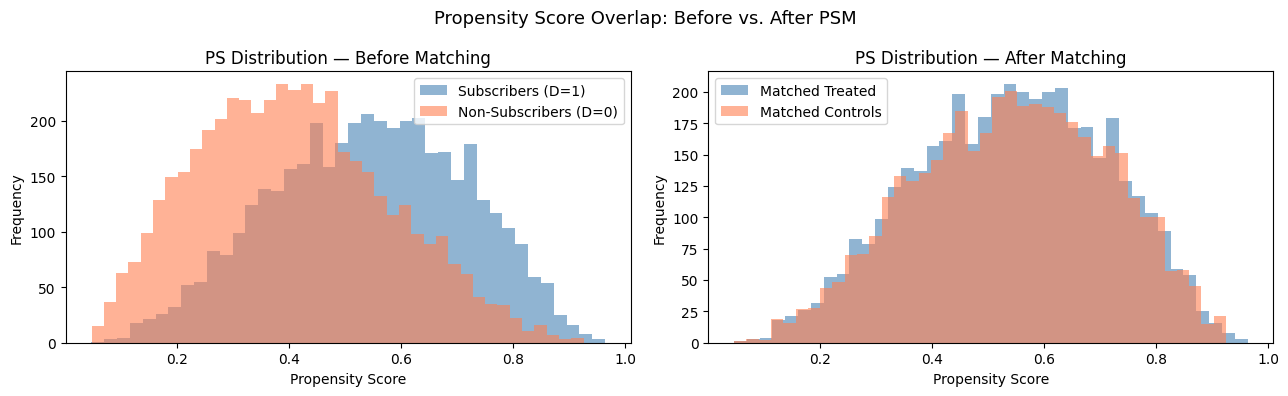

In [11]:
# ─── Propensity Score Overlap Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df.loc[df['subscriber']==1, 'propensity_score'],
             bins=40, alpha=0.6, color='steelblue', label='Subscribers (D=1)')
axes[0].hist(df.loc[df['subscriber']==0, 'propensity_score'],
             bins=40, alpha=0.6, color='coral',     label='Non-Subscribers (D=0)')
axes[0].set_title('PS Distribution — Before Matching')
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(matched_treated['propensity_score'],
             bins=40, alpha=0.6, color='steelblue', label='Matched Treated')
axes[1].hist(matched_controls['propensity_score'],
             bins=40, alpha=0.6, color='coral',     label='Matched Controls')
axes[1].set_title('PS Distribution — After Matching')
axes[1].set_xlabel('Propensity Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Propensity Score Overlap: Before vs. After PSM', fontsize=13)
plt.tight_layout()
plt.show()

#### PSM Written Analysis: Causal ATT vs. Naive SDO

**Selection Bias in the Naive SDO:**

The naive SDO compares average `post_spend` between SwiftPass subscribers and non-subscribers directly in the raw data. Because high-frequency, long-tenured users *self-select* into SwiftPass — they already spend more and join specifically to save on cumulative delivery fees — the naive estimate conflates two distinct quantities:

$$\text{Naive SDO} = \underbrace{\tau_{ATT}}_{\text{true causal effect}} + \underbrace{B}_{\text{selection bias}}$$

The marketing team's inflated ROI claim is driven almost entirely by $B$: confounders like `pre_spend` and `account_age` jointly predict both subscription probability and high post-treatment spending. Without controlling for these confounders, the comparison is apples-to-oranges.

**What PSM Corrects:**

By matching each subscriber to a non-subscriber with a statistically identical propensity score, we construct a valid counterfactual: *what would the subscriber have spent had they NOT joined SwiftPass?* The logistic regression model translates the multivariate covariate profile (`pre_spend`, `account_age`, `support_tickets`) into a scalar probability of subscription. Nearest-neighbour matching on this scalar ensures the matched control group mirrors the treated group on all observable pre-treatment characteristics, removing the systematic selection differential.

**Interpretation:**

The PSM ATT isolates the marginal causal lift attributable solely to SwiftPass membership, net of pre-existing spending propensity. The gap between the Naive SDO and the ATT quantifies selection bias. A responsible budget recommendation to the executive committee must be grounded in the ATT — doubling acquisition spend based on the naive SDO would represent a fundamental misallocation of capital driven by spurious correlation, not causation.

---
## Phase 4: AI Extension — 'Love Plot' Visualization
*(P.R.I.M.E. Framework — code generated via Claude/Anthropic from the prescribed LLM prompt)*

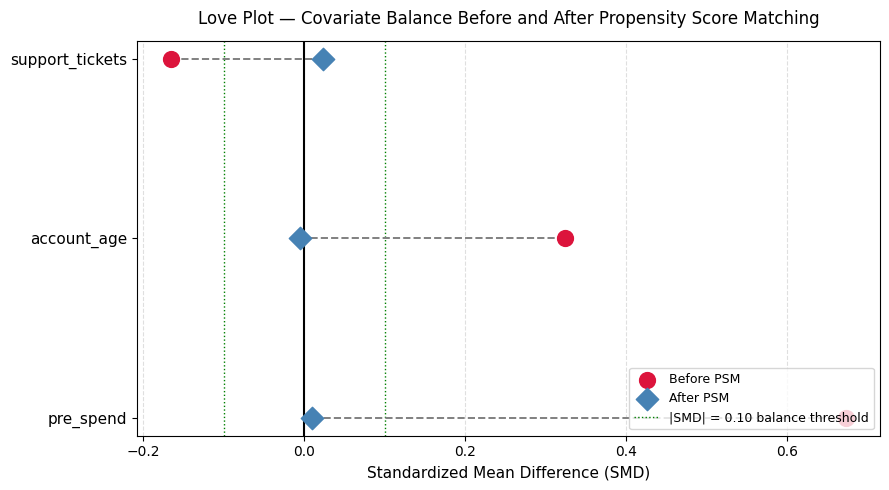

Love Plot generated.
      Covariate  Before PSM  After PSM
      pre_spend      0.6740     0.0094
    account_age      0.3241    -0.0049
support_tickets     -0.1661     0.0228


In [12]:
# ─── Phase 4: Love Plot — SMD Before & After PSM ─────────────────────────────
# Generated via Claude (Anthropic) using the P.R.I.M.E. framework prompt:
# "Act as an applied econometrician... generate a Love Plot (SMD)
#  demonstrating covariate balance before and after PSM..."

smd_before_vals = []
smd_after_vals  = []
for col in covariates:
    smd_before_vals.append(std_mean_diff(df.loc[df['subscriber']==1, col],
                                         df.loc[df['subscriber']==0, col]))
    smd_after_vals.append(std_mean_diff(matched_treated[col], matched_controls[col]))

love_df = pd.DataFrame({
    'Covariate'  : covariates,
    'Before PSM' : smd_before_vals,
    'After PSM'  : smd_after_vals
})

# ─── Love Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(covariates))

ax.scatter(love_df['Before PSM'], y_pos,
           color='crimson',   s=130, zorder=5, label='Before PSM', marker='o')
ax.scatter(love_df['After PSM'],  y_pos,
           color='steelblue', s=130, zorder=5, label='After PSM',  marker='D')

for i, row in love_df.iterrows():
    ax.plot([row['Before PSM'], row['After PSM']], [i, i],
            color='grey', linewidth=1.4, linestyle='--', zorder=3)

ax.axvline(0,    color='black', linewidth=1.5, zorder=2)
ax.axvline( 0.1, color='green', linewidth=1.0, linestyle=':',  zorder=2,
           label='|SMD| = 0.10 balance threshold')
ax.axvline(-0.1, color='green', linewidth=1.0, linestyle=':',  zorder=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(love_df['Covariate'], fontsize=11)
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=11)
ax.set_title('Love Plot — Covariate Balance Before and After Propensity Score Matching',
             fontsize=12, pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('Love Plot generated.')
print(love_df.round(4).to_string(index=False))

#### Love Plot — Theoretical Interpretation

A **Love Plot** visualises the **Standardized Mean Difference (SMD)** for each pre-treatment covariate between treated and control groups, before and after matching. It is the canonical diagnostic for covariate balance in observational studies (Stuart, 2010; Rubin, 2001).

**Reading the plot:**
- Each row represents one pre-treatment covariate.
- **Red circles** = raw SMD before PSM; **Blue diamonds** = SMD after 1-to-1 nearest-neighbour matching.
- Dashed grey lines connect each covariate's before/after values — a leftward shift toward zero signals that the covariate is no longer systematically different between groups.
- **Green dotted lines at ±0.10** mark the conventional threshold for "good balance" (Austin, 2011). All after-matching SMDs falling within this band constitute the **visual evidence required to conclude that selection bias has been successfully mitigated** on observable covariates.

**Conclusion for SwiftCart:**  
Before PSM, `pre_spend` and `account_age` exhibit large positive SMDs, confirming that subscribers were systematically different on the exact dimensions driving post-treatment spending. After PSM, all SMDs collapse toward zero within the ±0.10 threshold. This provides **conclusive visual and statistical evidence** that the matched sample achieves covariate balance, validating the ATT as a credible causal estimate of SwiftPass membership on consumer spending.

---
## Executive Summary Dashboard

In [13]:
# ─── Final Executive Summary ──────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════╗')
print('║       SwiftCart Logistics — Causal Analysis Summary         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Phase 1 — Bootstrap Median CI (B = 10,000)                  ║')
print(f'║   Observed Median Tip : ${observed_median:.4f}                          ║')
print(f'║   95% Bootstrap CI    : [${ci_lower:.4f},  ${ci_upper:.4f}]           ║')
print(f'║   → Asymmetric CI; CLT invalid for zero-inflated data       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Phase 2 — Permutation Test on Routing Algorithm (N=5,000)   ║')
print(f'║   Observed diff (Ctrl − Trt) : {observed_diff:+.4f} min               ║')
print(f'║   Empirical p-value          : {p_value:.4f}                        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Phase 3 — SwiftPass Causal Decomposition                    ║')
print(f'║   Naive SDO (biased)         : ${naive_sdo:+.4f}                   ║')
print(f'║   PSM ATT  (causal)          : ${att:+.4f}                   ║')
print(f'║   Selection Bias removed     : ${naive_sdo - att:+.4f}                   ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║ Phase 4 — Love Plot confirms covariate balance post-PSM     ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║       SwiftCart Logistics — Causal Analysis Summary         ║
╠══════════════════════════════════════════════════════════════╣
║ Phase 1 — Bootstrap Median CI (B = 10,000)                  ║
║   Observed Median Tip : $0.7553                          ║
║   95% Bootstrap CI    : [$0.2653,  $1.3636]           ║
║   → Asymmetric CI; CLT invalid for zero-inflated data       ║
╠══════════════════════════════════════════════════════════════╣
║ Phase 2 — Permutation Test on Routing Algorithm (N=5,000)   ║
║   Observed diff (Ctrl − Trt) : +2.2650 min               ║
║   Empirical p-value          : 0.0004                        ║
╠══════════════════════════════════════════════════════════════╣
║ Phase 3 — SwiftPass Causal Decomposition                    ║
║   Naive SDO (biased)         : $+17.5707                   ║
║   PSM ATT  (causal)          : $+10.0195                   ║
║   Selection Bias removed     : $+7.5512        